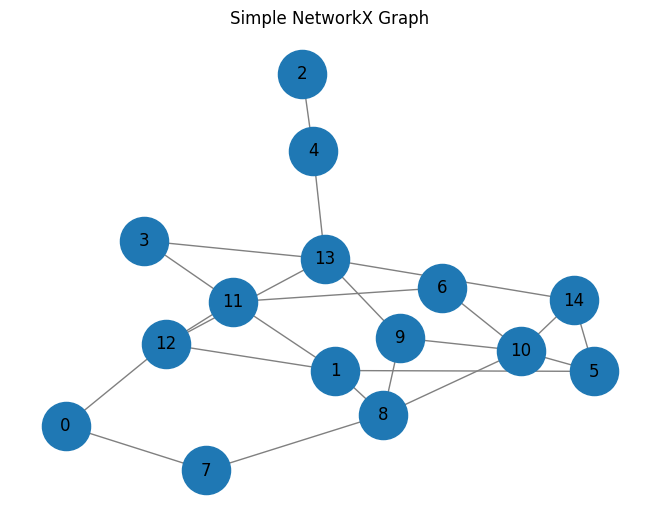

In [158]:
from functions import *


class EGraph():
    def __init__(self, N, P, b, c, w=0.01):
        self.N = N
        self.P = P
        self.b = b
        self.c = c
        self.w = w
        self.graph = gnp_random_connected_graph(N,P)
        self.W, self.k = self.generate()

    def generate(self):
        num_neighbors = [len(self.graph.adj[n]) for n in self.graph.nodes]
        k = np.mean(num_neighbors)
        for node,attributes in self.graph.nodes(data=True):
            attributes['fitness'] = 1
            attributes['strategy'] = 'defect'

        W = np.zeros((N,N))

        for node in self.graph.adj:
            for nb in self.graph.adj[node]:
                W[node][nb] = 1/self.graph.degree(node)

        r = random.randint(0,N-1)
        # print("hello")
        # print("r = ", r)

        self.graph.nodes[r]['strategy'] = 'cooperate'

        return W, k
    
    def calculate_fitness(self):


        for node in self.graph.nodes:
            num_neighbors = len(self.graph.adj[node])
            num_coop = 0
            for nb in self.graph.adj[node]:
                if self.graph.nodes[nb]['strategy'] == 'cooperate':
                    num_coop+=1

            if self.graph.nodes[node]['strategy'] == 'cooperate':
                payoff = self.b*num_coop - self.c*num_neighbors
            else:
                payoff = self.b*num_coop

            self.graph.nodes[node]['fitness'] = 1-self.w + self.w*payoff
            if self.graph.nodes[node]['fitness'] < 0:
                self.graph.nodes[node]['fitness'] = 0
            # print(node,self.graph.nodes[node]['fitness'])


    def update_rule(self):
        '''Death-Birth'''
        fitness_values = [self.graph.nodes[n]['fitness'] for n in range(self.N)]
        # print(fitness_values)
        sum_fitness = sum(fitness_values)
        probs = [f/sum_fitness for f in fitness_values]

        
        death = np.random.choice(self.graph.nodes, p=probs) 


        selected_node = np.random.choice(self.graph.nodes, p=self.W[death])

        for key in self.graph.nodes[death].keys():
            self.graph.nodes[death][key] = self.graph.nodes[selected_node][key]
        

    def get_stats(self):

        
        strategies=[self.graph.nodes[n]['strategy'] for n in range(self.N)]

        num_coop = strategies.count('cooperate')
        num_def = strategies.count('defect')

        return num_coop, num_def
    


        

N = 15
EPOCH = 100
# k is about equal to Np+2

# p_values = [2/N, 4/N, 6/N, 8/N, 10/N]
P = 2/N
RATIO = (240,10)
# ratios = [(16,10),(17,10),(18,10),(19,10),(20,10),(21,10),(22,10),(23,10),(24,10)]
          

# print("p, k, b/c, result\n")


G = EGraph(N,P, RATIO[0], RATIO[1])

nx.draw(G.graph, with_labels=True, edge_color='gray', node_size=1200)
#  , node_color='lightblue'
#  3. Display the plot
plt.title("Simple NetworkX Graph")
plt.show()


# graph, W, k = create_graph(N, P)
# result = "inconclusive"
# length=EPOCH
# for n in range(EPOCH):
#     calculate_fitness(graph, RATIO[0],RATIO[1], .01)
#     update_rule(graph, W)
#     x,y = get_stats(graph)
#     print(x,y)
#     if x == 0:
#         result = "extinct"
        
#     elif x==N:
#         result = "fixation"
        



        
# print(f"{P},{k},{RATIO[0]/RATIO[1]}, {result}\n")

In [159]:
print(G.graph.nodes(data=True))

[(0, {'fitness': 1, 'strategy': 'defect'}), (1, {'fitness': 1, 'strategy': 'defect'}), (2, {'fitness': 1, 'strategy': 'defect'}), (3, {'fitness': 1, 'strategy': 'defect'}), (4, {'fitness': 1, 'strategy': 'defect'}), (5, {'fitness': 1, 'strategy': 'defect'}), (6, {'fitness': 1, 'strategy': 'defect'}), (7, {'fitness': 1, 'strategy': 'defect'}), (8, {'fitness': 1, 'strategy': 'defect'}), (9, {'fitness': 1, 'strategy': 'defect'}), (10, {'fitness': 1, 'strategy': 'defect'}), (11, {'fitness': 1, 'strategy': 'cooperate'}), (12, {'fitness': 1, 'strategy': 'defect'}), (13, {'fitness': 1, 'strategy': 'defect'}), (14, {'fitness': 1, 'strategy': 'defect'})]


In [160]:
cooperators = []
defectors = []

#initialize
x,y = G.get_stats()
cooperators.append(x)
defectors.append(y)


for n in range(100):

    G.calculate_fitness()
    G.update_rule()
    x,y = G.get_stats()
    if x==0:
        break
    cooperators.append(x)
    defectors.append(y)

print(cooperators)
print(defectors)

[1, 2, 2, 2, 2, 2, 2, 3, 3, 4, 3, 4, 5, 5, 5, 6, 6, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 4, 3, 3, 3, 3, 4, 5, 5, 5, 5, 4, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 5, 5, 5, 5, 5, 6, 6, 6, 7, 8, 8, 9, 10, 10, 10, 10, 10, 9, 8, 8, 8, 9, 10, 10, 10, 10, 11, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13]
[14, 13, 13, 13, 13, 13, 13, 12, 12, 11, 12, 11, 10, 10, 10, 9, 9, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 11, 12, 12, 12, 12, 11, 10, 10, 10, 10, 11, 12, 12, 12, 12, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 11, 10, 10, 10, 10, 10, 9, 9, 9, 8, 7, 7, 6, 5, 5, 5, 5, 5, 6, 7, 7, 7, 6, 5, 5, 5, 5, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2]
